# Section 1: Data Cleaning and Exploratory Analysis
## 1.1 Load and Merge Raw Data
Combine all city-level weekday/weekend CSV files into one analysis table, create the log-price target, encode categorical fields, and summarize the merged data.

**Output.** Displays dataset dimensions, city counts, weekday/weekend counts, and writes the cleaned structure to memory for later cells.

In [1]:
from pathlib import Path
Path("plots_overleaf").mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import OneHotEncoder
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

data_dir  = os.path.expanduser('~/Desktop/189 Project/Data')
out_path  = os.path.expanduser('~/Desktop/189 Project/merged_data.csv')

frames = []
for fname in os.listdir(data_dir):
    if not fname.endswith('.csv'):
        continue

    # Parse city and weekday/weekend status from the filename.
    stem = fname.replace('.csv', '')
    parts = stem.rsplit('_', 1)
    city_name = parts[0].lower().capitalize()
    day_type  = parts[1].lower()

    df = pd.read_csv(os.path.join(data_dir, fname), index_col=0)
    df['city'] = city_name
    df['is_weekday'] = 1 if day_type == 'weekdays' else 0

    frames.append(df)

merged = pd.concat(frames, ignore_index=True)

# Add log-transformed price target.
merged.insert(merged.columns.get_loc('realSum') + 1, 'logSum', np.log(merged['realSum']))

# One-hot encode room type.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
room_encoded = ohe.fit_transform(merged[['room_type']])
room_cols = ['room_type_apt', 'room_type_private', 'room_type_shared']
room_pos = merged.columns.get_loc('room_type')
merged.drop(columns=['room_type'], inplace=True)
for i, col in enumerate(room_cols):
    merged.insert(room_pos + i, col, room_encoded[:, i].astype(int))

# Drop redundant room indicators.
merged.drop(columns=['room_shared', 'room_private'], inplace=True)

# Encode superhost status as 0/1.
superhost_pos = merged.columns.get_loc('host_is_superhost')
merged.insert(superhost_pos, 'is_superhost', merged['host_is_superhost'].astype(int))
merged.drop(columns=['host_is_superhost'], inplace=True)

# Remove unused location and normalized-index columns.
merged.drop(columns=['lng', 'lat', 'attr_index_norm', 'rest_index_norm'], inplace=True)

load_summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Cities'],
    'Value': [len(merged), merged.shape[1], merged['city'].nunique()],
})
city_counts = merged['city'].value_counts().sort_index().rename_axis('City').reset_index(name='Rows')
weekday_counts = (
    merged['is_weekday']
    .map({1: 'Weekday', 0: 'Weekend'})
    .value_counts()
    .rename_axis('Period')
    .reset_index(name='Rows')
)

display(load_summary)
display(city_counts)
display(weekday_counts)


,Metric,Value
0,Rows,51707
1,Columns,18
2,Cities,10


,City,Rows
0,Amsterdam,2080
1,Athens,5280
2,Barcelona,2833
3,Berlin,2484
4,Budapest,4022
5,Lisbon,5763
6,London,9993
7,Paris,6688
8,Rome,9027
9,Vienna,3537


,Period,Rows
0,Weekend,26207
1,Weekday,25500


## 1.2 Preview Merged Columns
Inspect the merged DataFrame after feature engineering to confirm that columns are in the expected format.

**Output.** Shows the first rows of the merged dataset.

In [2]:
merged.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


## 1.3 Pre-Cleaning Price Summary
Measure the raw price distribution before outlier removal.

**Output.** Displays descriptive statistics for `realSum`.

In [3]:
def descriptive_stats(series, label):
    return {
        'Variable': label,
        'Mean':     series.mean(),
        'Median':   series.median(),
        'Std':      series.std(),
        'Min':      series.min(),
        'Max':      series.max(),
        'Skewness': stats.skew(series),
        'Kurtosis': stats.kurtosis(series),
    }

pre_removal = pd.DataFrame([
    descriptive_stats(merged['realSum'], 'realSum (€)'),
]).set_index('Variable').round(4)

display(pre_removal)


,Mean,Median,Std,Min,Max,Skewness,Kurtosis
Variable,,,,,,,
realSum (€),279.8796,211.3431,327.9484,34.7793,18545.4503,21.4193,831.2754


## 1.4 Missing Values and Outlier Removal
Check missingness and remove extreme prices above the 99th percentile so later summaries and models are less dominated by outliers.

**Output.** Displays missing-value and cleaning-summary tables, then saves `merged_data.csv`.

In [4]:

# Summarize missing values.
missing = merged.isnull().sum()
missing = missing[missing > 0]
missing_df = (
    missing.rename_axis('Column').reset_index(name='Missing values')
    if not missing.empty
    else pd.DataFrame({'Status': ['No missing values found']})
)

display(missing_df)

# Remove prices above the 99th percentile.
p99 = merged['realSum'].quantile(0.99)
n_before = len(merged)
merged = merged[merged['realSum'] <= p99].reset_index(drop=True)
n_removed = n_before - len(merged)

cleaning_summary = pd.DataFrame({
    'Metric': [
        '99th percentile threshold (€)',
        'Rows before cleaning',
        'Rows removed',
        'Rows remaining',
        'Columns remaining',
    ],
    'Value': [round(p99, 2), n_before, n_removed, len(merged), merged.shape[1]],
})

display(cleaning_summary)

# Save the cleaned dataset for later sections.
merged.to_csv(out_path, index=False)


,Status
0,No missing values found


,Metric,Value
0,99th percentile threshold (€),1160.84
1,Rows before cleaning,51707.00
2,Rows removed,518.00
3,Rows remaining,51189.00
4,Columns remaining,18.00


## 1.5 Post-Cleaning Descriptive Statistics
Summarize the cleaned price variables overall and by city.

**Output.** Displays descriptive statistics for `realSum` and `logSum` at both levels.

In [5]:

def descriptive_stats(series, label):
    return {
        'Variable': label,
        'Mean':     series.mean(),
        'Median':   series.median(),
        'Std':      series.std(),
        'Min':      series.min(),
        'Max':      series.max(),
        'Skewness': stats.skew(series),
        'Kurtosis': stats.kurtosis(series),
    }

overall = pd.DataFrame([
    descriptive_stats(merged['realSum'], 'realSum (€)'),
    descriptive_stats(merged['logSum'],  'logSum'),
]).set_index('Variable').round(4)

display(overall)

city_stats = []
for city in merged['city'].unique():
    subset = merged[merged['city'] == city]
    r = descriptive_stats(subset['realSum'], f'{city}')
    l = descriptive_stats(subset['logSum'],  f'{city}')
    r['Type'] = 'realSum'; l['Type'] = 'logSum'
    city_stats.extend([r, l])

city_df = pd.DataFrame(city_stats).rename(columns={'Variable': 'City'})             .set_index(['City', 'Type']).round(4)

display(city_df)


,Mean,Median,Std,Min,Max,Skewness,Kurtosis
Variable,,,,,,,
realSum (€),261.2559,208.9587,170.2742,34.7793,1159.9520,1.9397,4.5245
logSum,5.3987,5.3421,0.5603,3.5490,7.0561,0.3743,-0.1283


Mean    Median       Std       Min        Max  \
City      Type                                                         
Amsterdam realSum  496.1198  437.6304  222.6855  128.8871  1155.5316   
          logSum     6.1095    6.0814    0.4424    4.8589     7.0523   
Barcelona realSum  272.9731  208.2994  175.2603   69.5883  1117.8346   
          logSum     5.4532    5.3390    0.5307    4.2426     7.0191   
Rome      realSum  202.6454  182.5918   98.4895   46.0571  1152.5963   
          logSum     5.2171    5.2073    0.4238    3.8299     7.0498   
Berlin    realSum  232.7139  190.1234  134.9293   64.9715  1159.4372   
          logSum     5.3241    5.2477    0.4780    4.1739     7.0557   
Budapest  realSum  172.9662  152.9821   87.7106   34.7793  1078.8645   
          logSum     5.0622    5.0303    0.4083    3.5490     6.9837   
Vienna    realSum  230.3943  208.4940  103.0407   63.5767   892.4105   
          logSum     5.3554    5.3399    0.4038    4.1522     6.7939   
London    realSum  323.1348  257.7671  205.4038   54.3287  1159.9520   
          logSum     5.6003    5.5521    0.5893    3.9951     7.0561   
Lisbon    realSum  237.6293  225.3752  105.8511   70.5910   987.1013   
          logSum     5.3787    5.4178    0.4314    4.2569     6.8948   
Athens    realSum  148.2598  127.7154   81.1900   42.8843  1043.2826   
          logSum     4.8929    4.8498    0.4394    3.7585     6.9501   
Paris     realSum  367.6789  312.9369  187.2802   92.7393  1152.9499   
          logSum     5.7947    5.7460    0.4670    4.5298     7.0501   

                   Skewness  Kurtosis  
City      Type                         
Amsterdam realSum    0.8449   -0.0085  
          logSum     0.0463   -0.7242  
Barcelona realSum    1.8318    3.4001  
          logSum     0.6882   -0.1955  
Rome      realSum    2.3233   10.5916  
          logSum     0.3186    0.3492  
Berlin    realSum    2.1514    6.2278  
          logSum     0.6376    0.1253  
Budapest  realSum    3.1629   16.8943  
          logSum     0.4958    1.5234  
Vienna    realSum    1.8167    5.4652  
          logSum     0.2404    0.2481  
London    realSum    1.3954    1.7551  
          logSum     0.2402   -0.7103  
Lisbon    realSum    1.4426    4.1824  
          logSum    -0.0770   -0.1276  
Athens    realSum    3.0175   16.1468  
          logSum     0.5729    0.8673  
Paris     realSum    1.4358    2.1902  
          logSum     0.2467   -0.2527

## 1.6 Overall Price Distribution
Visualize how the raw and log-transformed price distributions behave after cleaning.

**Output.** Saves the overall distribution plot to the `plots` folder.

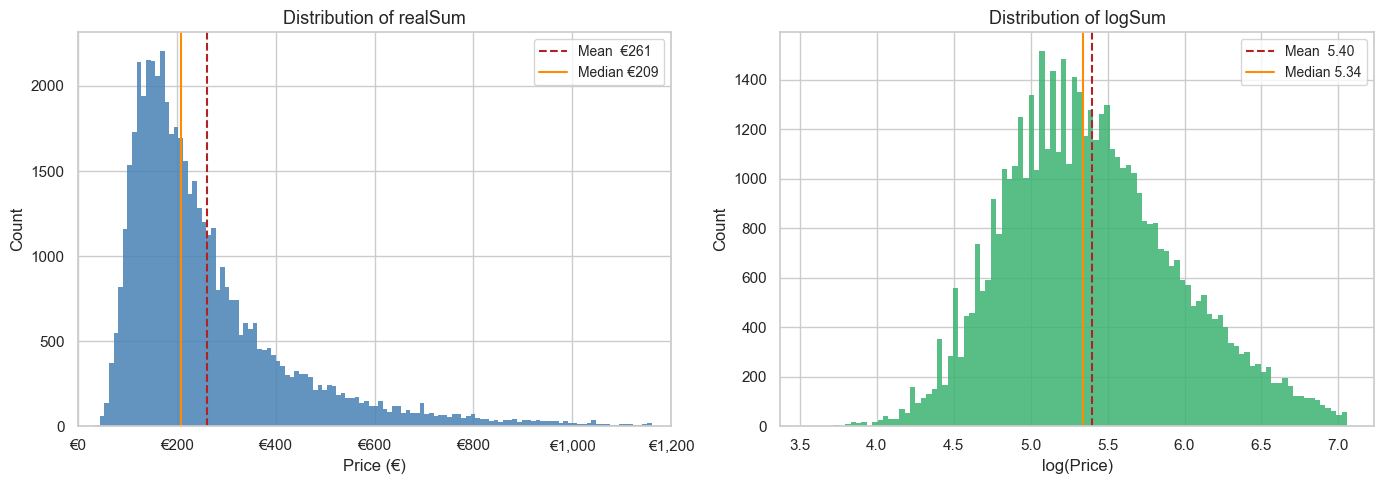

In [6]:
sns.set_theme(style='whitegrid', palette='muted')

realSum = merged['realSum']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(realSum, bins=120, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(realSum.mean(),   color='firebrick', lw=1.5, linestyle='--', label=f'Mean  €{realSum.mean():.0f}')
ax.axvline(realSum.median(), color='darkorange', lw=1.5, linestyle='-',  label=f'Median €{realSum.median():.0f}')
ax.set_xlim(0, 1200)
ax.set_xlabel('Price (€)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of realSum', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(fontsize=10)

ax = axes[1]
ax.hist(merged['logSum'], bins=100, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(merged['logSum'].mean(),   color='firebrick', lw=1.5, linestyle='--', label=f'Mean  {merged["logSum"].mean():.2f}')
ax.axvline(merged['logSum'].median(), color='darkorange', lw=1.5, linestyle='-',  label=f'Median {merged["logSum"].median():.2f}')
ax.set_xlabel('log(Price)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of logSum', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('plots_overleaf/section1_PlotDistribution1_overall.png', dpi=300, bbox_inches='tight')
plt.show()


## 1.7 City-Level Price Distributions
Compare cleaned prices across cities using KDE and boxplot views.

**Output.** Saves city-level distribution plots to the `plots` folder.

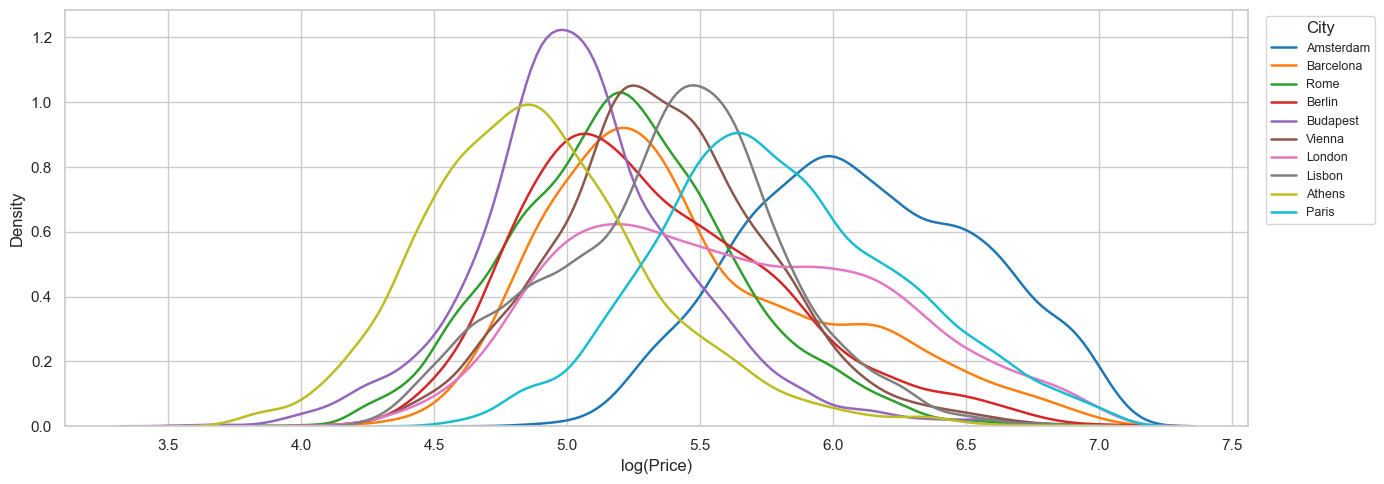

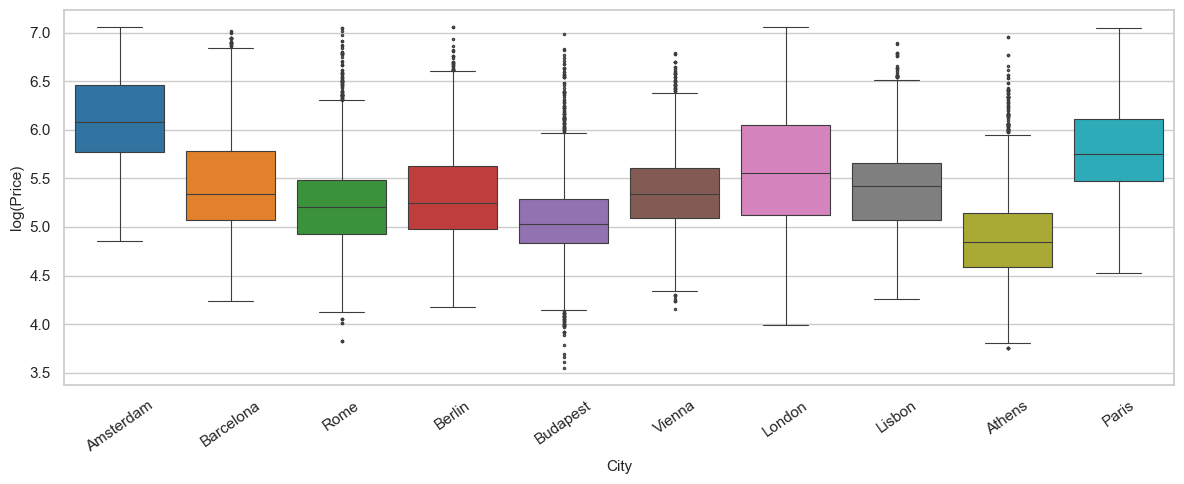

In [7]:

fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('tab10', n_colors=10)
for city, color in zip(merged['city'].unique(), palette):
    subset = merged[merged['city'] == city]['logSum']
    sns.kdeplot(subset, ax=ax, label=city, color=color, linewidth=1.8)
ax.set_xlabel('log(Price)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(title='City', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('plots_overleaf/section1_PlotDistribution2_logPriceKDEByCity.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=merged, x='city', y='logSum',
            hue='city', palette='tab10',
            legend=False, ax=ax, fliersize=1.5, linewidth=0.8)
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('log(Price)', fontsize=11)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('plots_overleaf/section1_PlotDistribution3_priceBoxplotByCity.png', dpi=300, bbox_inches='tight')
plt.show()


## 1.8 Amsterdam and Athens KDE Emphasis
Replot the city-level log-price KDE with Amsterdam and Athens fully opaque while the other city curves are faded for comparison.

**Output.** Saves the emphasized Amsterdam/Athens KDE plot to the `plots_overleaf` folder.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('tab10', n_colors=10)
emphasis_cities = {'Amsterdam', 'Athens'}

for city, color in zip(merged['city'].unique(), palette):
    subset = merged[merged['city'] == city]['logSum']
    is_emphasis = city in emphasis_cities
    sns.kdeplot(
        subset,
        ax=ax,
        label=city,
        color=color,
        linewidth=1.8,
        alpha=1.0 if is_emphasis else 0.18,
        zorder=3 if is_emphasis else 1,
    )

ax.set_xlabel('log(Price)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(title='City', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(
    'plots_overleaf/section1_PlotDistribution4_logPriceKDEAmsterdamAthensEmphasis.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()
